# Assignment 12

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic_dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# Q1 : 
Create a Bar Chart to show the survival rate of passengers from each Embarked port.

X-axis: Embarked

Y-axis: Average of Survived

Add proper title and labels.

Identify which port has the highest survival rate.

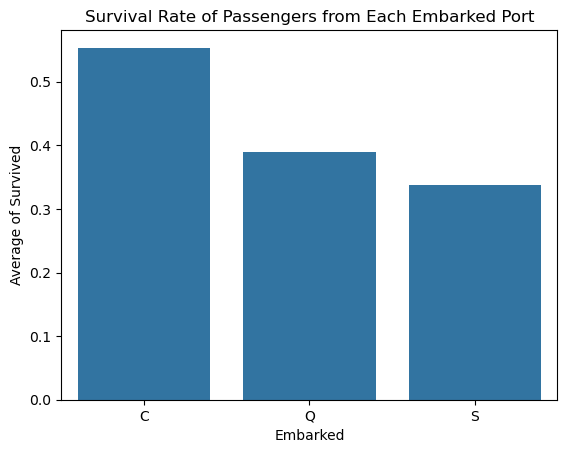

Port with the highest survival rate: C


In [15]:
survival_rate = df.groupby("Embarked")["Survived"].mean()

sns.barplot(x=survival_rate.index, y=survival_rate.values)

plt.title("Survival Rate of Passengers from Each Embarked Port")
plt.xlabel("Embarked")
plt.ylabel("Average of Survived")

plt.show()

print("Port with the highest survival rate:", survival_rate.idxmax())

# Q2. Create a new column FamilySize using:

FamilySize = SibSp + Parch + 1

Then create a Count Plot showing the number of passengers for each family-size category.

X-axis: FamilySize

Y-axis: Number of Passengers

Identify the most common family size.

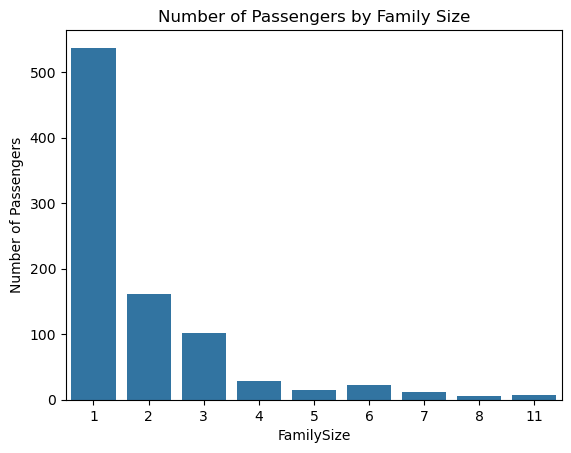

Most common family size: 1


In [11]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

sns.countplot(x="FamilySize", data=df)

plt.title("Number of Passengers by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Number of Passengers")
plt.show()

print("Most common family size:", df["FamilySize"].mode()[0])

# Q3. 
### Create a Box Plot to compare Fare across different Pclass, while separating passengers by Sex.

X-axis: Pclass

Y-axis: Fare

Use Sex as hue.

Identify which group paid the highest fares.

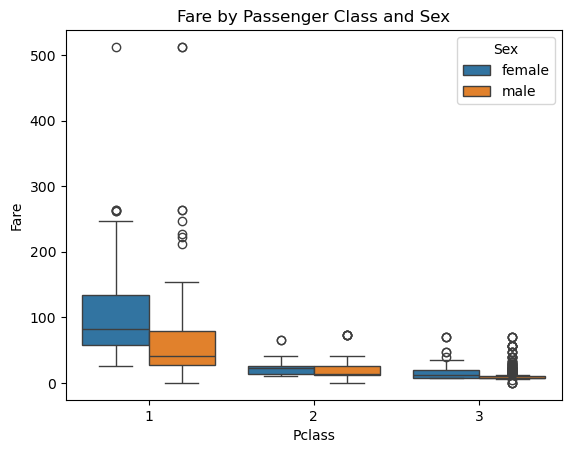

Group with highest fares: (np.int64(1), 'female')


In [12]:
sns.boxplot(x="Pclass", y="Fare", hue="Sex", data=df)

plt.title("Fare by Passenger Class and Sex")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

print(
    "Group with highest fares:",
    df.groupby(["Pclass", "Sex"])["Fare"].max().idxmax()
)

# Q4. 

#### Using the FamilySize column created in Q2, create a Line Plot showing the average survival rate for each family size.

X-axis: FamilySize

Y-axis: Survival Rate

Add markers to the line.

Identify the family size with the highest survival rate.

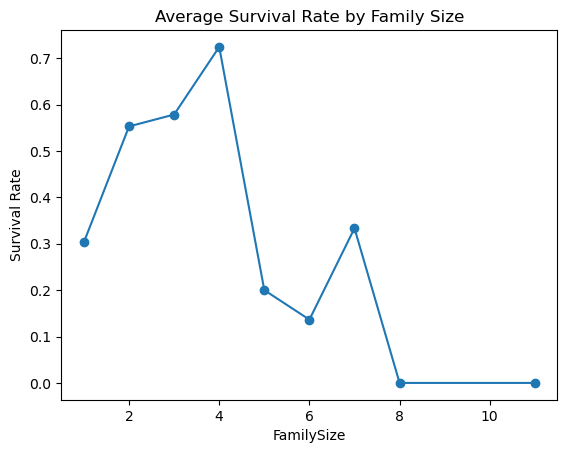

Family size with highest survival rate: 4


In [13]:
family_survival = df.groupby("FamilySize")["Survived"].mean()

plt.plot(
    family_survival.index,
    family_survival.values,
    marker="o"
)

plt.title("Average Survival Rate by Family Size")
plt.xlabel("FamilySize")
plt.ylabel("Survival Rate")
plt.show()

print(
    "Family size with highest survival rate:",
    family_survival.idxmax()
)

# Q5.Passenger Class & Gender Survival Comparison
Create a stacked bar chart showing the number of Survived and Not Survived passengers for each combination of Pclass and Sex.

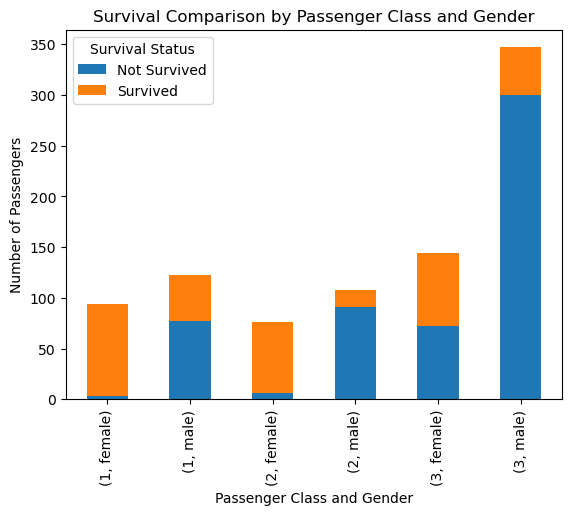

In [14]:
survival_comparison = pd.crosstab(
    [df["Pclass"], df["Sex"]],
    df["Survived"]
)

survival_comparison.columns = ["Not Survived", "Survived"]

survival_comparison.plot(
    kind="bar",
    stacked=True
)

plt.title("Survival Comparison by Passenger Class and Gender")
plt.xlabel("Passenger Class and Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survival Status")
plt.show()

# Assignment Completed